# 04 - Audit-Driven EDA (v4_exact + v2)

Notebook 4 duoc thiet ke theo 3 phase, chi doc du lieu audit/artifact da sinh ra, khong tao du lieu gia:

1. EDA sau tien xu ly (v4_exact)
2. EDA sau trich chon dac trung (v2)
3. EDA artifact eval mo hinh sau train va kiem tra feature

Nguyen tac:
- Moi ket luan phai truy duoc den file audit cu the
- Phase 2 overlap/correlation chi dung split train_core de tranh leakage
- Neu artifact khong ton tai, notebook se bao ro va skip phase, khong bịa so lieu

In [42]:
from __future__ import annotations

from datetime import datetime
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_ROOT = PROJECT_ROOT / 'data' / 'processed_v4_rgb248_r4_exact'
MANIFEST_PATH = PROCESSED_ROOT / 'manifest.csv'
SNAPSHOT_SUMMARY_PATH = PROJECT_ROOT / 'audit_output' / 'validation' / 'spec_v4_20260319' / 'snapshot_summary.json'
GEOMETRY_FRONTIER_PATH = PROJECT_ROOT / 'audit_output' / 'validation' / 'spec_v4_20260319' / 'geometry_frontier_mult8.csv'
RESIDUE_SCAN_PATH = PROJECT_ROOT / 'audit_output' / 'validation' / 'spec_v4_20260319' / 'geometry_residue_scan_crop_248.csv'

FEATURE_TABLE_PATH = PROJECT_ROOT / 'features' / 'feature_extraction_v2_rgb248_exact.csv'
FEATURE_STUDY_DIR = PROJECT_ROOT / 'audit_output' / 'studies' / 'feature_spec_v2_validation_20260325'
FEATURE_SET_METRICS_PATH = FEATURE_STUDY_DIR / 'feature_set_metrics.csv'
FEATURE_STUDY_SUMMARY_PATH = FEATURE_STUDY_DIR / 'summary.json'
CONTROL_CORR_PATH = FEATURE_STUDY_DIR / 'diagnostics' / 'control_minimal_correlation_matrix.csv'

TRAIN_AUDIT_DIR = PROJECT_ROOT / 'audit_output' / 'validation' / 'training_v2_phase_closure_20260403'
PHASE1_DIR = TRAIN_AUDIT_DIR / 'phase1_clean_benchmark'
PHASE2_DIR = TRAIN_AUDIT_DIR / 'phase2_model_nuisance'
PHASE3_DIR = TRAIN_AUDIT_DIR / 'phase3_degradation_suite'
PHASE4_DIR = TRAIN_AUDIT_DIR / 'phase4_family_ablation'
PHASE5_DIR = TRAIN_AUDIT_DIR / 'phase5_phase_closure'

CANDIDATE_METRICS_PATH = PHASE1_DIR / 'candidate_val_metrics.csv'
SELECTED_METRICS_PATH = PHASE1_DIR / 'selected_model_metrics.csv'
OOD_BY_GENERATOR_PATH = PHASE1_DIR / 'selected_model_ood_by_generator.csv'
CLEAN_CFA_GATE_COVERAGE_PATH = PHASE1_DIR / 'clean_cfa_gate_coverage.csv'
FEATURE_IMPORTANCE_PATH = PHASE1_DIR / 'selected_model_feature_importance.csv'
FAMILY_IMPORTANCE_PATH = PHASE1_DIR / 'selected_model_family_importance.csv'

AUC_NAT_METRICS_PATH = PHASE2_DIR / 'model_level_auc_nat.csv'
DEGRADATION_GAP_PATH = PHASE3_DIR / 'degradation_gap_summary.csv'
BRANCH_CLOSURE_PATH = PHASE4_DIR / 'branch_closure_summary.csv'
PHASE_CLOSURE_JSON = PHASE5_DIR / 'phase_closure_summary.json'

MODEL_PARAM_DIR = PROJECT_ROOT / 'models' / 'param'
RUN_NAME = os.getenv('EDA4_RUN_NAME', f"eda_visualization_v4_{datetime.now().strftime('%Y%m%d')}")
VIS_ROOT = PROJECT_ROOT / 'audit_output' / 'validation' / RUN_NAME
PHASE1_PLOT_DIR = VIS_ROOT / 'phase1_preprocess'
PHASE2_PLOT_DIR = VIS_ROOT / 'phase2_features'
PHASE3_PLOT_DIR = VIS_ROOT / 'phase3_model'
for path in [PHASE1_PLOT_DIR, PHASE2_PLOT_DIR, PHASE3_PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

def load_csv(path: Path, *, required: bool = True) -> pd.DataFrame | None:
    if not path.exists():
        if required:
            raise FileNotFoundError(f'Missing required CSV: {path}')
        print(f'[SKIP] Missing optional CSV: {path}')
        return None
    return pd.read_csv(path)

def load_json(path: Path, *, required: bool = True) -> dict:
    if not path.exists():
        if required:
            raise FileNotFoundError(f'Missing required JSON: {path}')
        print(f'[SKIP] Missing optional JSON: {path}')
        return {}
    return json.loads(path.read_text(encoding='utf-8'))

def overlap_coefficient(x0: np.ndarray, x1: np.ndarray, bins: int = 60) -> float:
    x = np.concatenate([x0, x1])
    if x.size == 0:
        return float('nan')
    if np.allclose(np.nanmin(x), np.nanmax(x)):
        return 1.0
    hist0, edges = np.histogram(x0, bins=bins, range=(np.nanmin(x), np.nanmax(x)), density=True)
    hist1, _ = np.histogram(x1, bins=bins, range=(np.nanmin(x), np.nanmax(x)), density=True)
    width = np.diff(edges)
    return float(np.sum(np.minimum(hist0, hist1) * width))

print({
    'run_name': RUN_NAME,
    'manifest': str(MANIFEST_PATH),
    'feature_table': str(FEATURE_TABLE_PATH),
    'training_audit_dir': str(TRAIN_AUDIT_DIR),
    'vis_root': str(VIS_ROOT),
})


{'run_name': 'eda_visualization_v4_20260403', 'manifest': 'C:\\Users\\USER\\Desktop\\ai_detector_img\\data\\processed_v4_rgb248_r4_exact\\manifest.csv', 'feature_table': 'C:\\Users\\USER\\Desktop\\ai_detector_img\\features\\feature_extraction_v2_rgb248_exact.csv', 'training_audit_dir': 'C:\\Users\\USER\\Desktop\\ai_detector_img\\audit_output\\validation\\training_v2_phase_closure_20260403', 'vis_root': 'C:\\Users\\USER\\Desktop\\ai_detector_img\\audit_output\\validation\\eda_visualization_v4_20260403'}


## Phase 1 - EDA Sau Tien Xu Ly

Phase nay dung manifest preprocess v4 va artifact geometry audit de kiem tra: yield theo nhan, support gate, crop frontier va residue choice.

In [43]:
manifest = load_csv(MANIFEST_PATH, required=True)
manifest['support'] = pd.to_numeric(manifest['support'], errors='coerce')
snapshot_summary = load_json(SNAPSHOT_SUMMARY_PATH, required=False)
geometry_frontier = load_csv(GEOMETRY_FRONTIER_PATH, required=False)
residue_scan = load_csv(RESIDUE_SCAN_PATH, required=False)
status_by_label = manifest.groupby(['label', 'status']).size().unstack(fill_value=0)
pre_summary = {
    'n_total': int(len(manifest)),
    'n_accepted': int((manifest['status'] == 'ACCEPTED').sum()),
    'status_counts': manifest['status'].value_counts().to_dict(),
    'status_by_label': status_by_label.to_dict(),
    'snapshot_summary': snapshot_summary,
}
pre_summary

{'n_total': 87971,
 'n_accepted': 85615,
 'status_counts': {'ACCEPTED': 85615,
  'LOW_SUPPORT': 1573,
  'UNSUPPORTED_INPUT': 783},
 'status_by_label': {'ACCEPTED': {'ai': 43992, 'nature': 41623},
  'LOW_SUPPORT': {'ai': 0, 'nature': 1573},
  'UNSUPPORTED_INPUT': {'ai': 0, 'nature': 783}},
 'snapshot_summary': {'raw_file_count': 87971,
  'metadata_rows': 88007,
  'matched_metadata_rows': 87971,
  'stale_metadata_rows': 36,
  'raw_snapshot_sha256': 'cfd6a842ff6a5e8ad5f78d8321d4bff3700127f993bb262175aca9b93a74e92f'}}

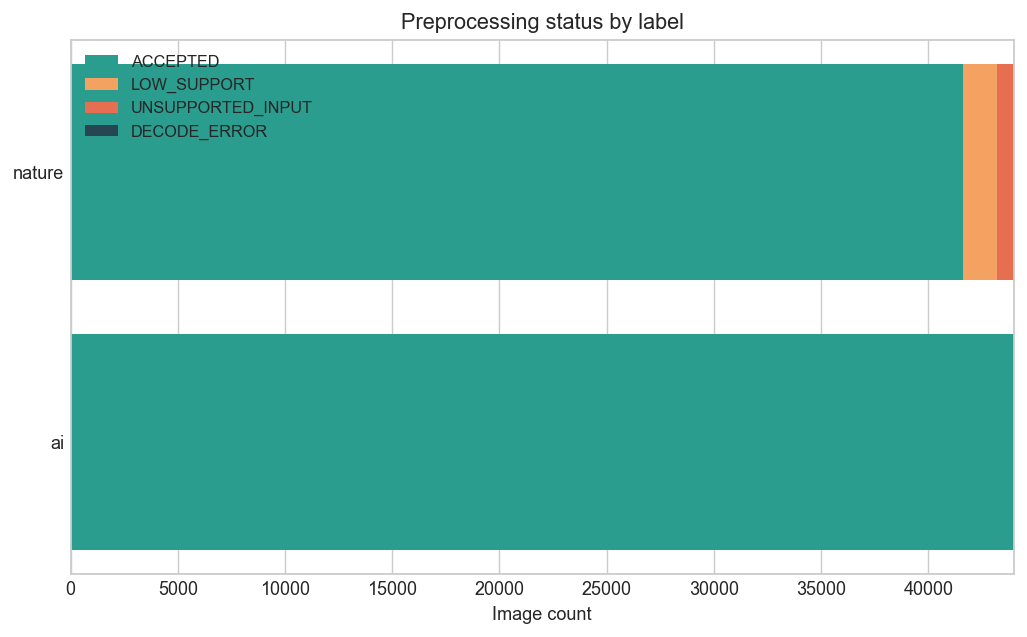

In [44]:
status_order = ['ACCEPTED', 'LOW_SUPPORT', 'UNSUPPORTED_INPUT', 'DECODE_ERROR']
status_colors = {'ACCEPTED': '#2a9d8f', 'LOW_SUPPORT': '#f4a261', 'UNSUPPORTED_INPUT': '#e76f51', 'DECODE_ERROR': '#264653'}
fig, ax = plt.subplots(figsize=(8, 5))
table = status_by_label.reindex(columns=status_order, fill_value=0)
left = np.zeros(len(table), dtype=float)
y = np.arange(len(table))
for status in status_order:
    values = table[status].to_numpy(dtype=float)
    ax.barh(y, values, left=left, color=status_colors[status], label=status)
    left += values
ax.set_yticks(y)
ax.set_yticklabels(table.index.tolist())
ax.set_xlabel('Image count')
ax.set_title('Preprocessing status by label')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(PHASE1_PLOT_DIR / 'status_by_label.png', dpi=170)
plt.show()

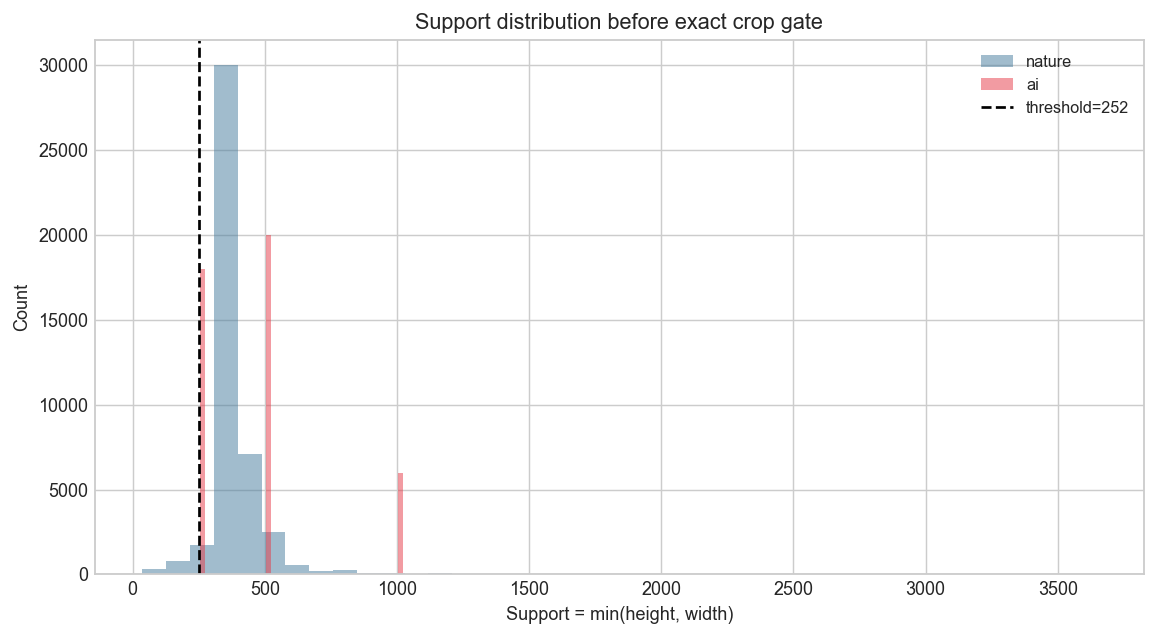

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in [('nature', '#457b9d'), ('ai', '#e63946')]:
    values = manifest.loc[manifest['label'] == label, 'support'].dropna().to_numpy(dtype=float)
    if values.size:
        ax.hist(values, bins=40, alpha=0.5, label=label, color=color)
ax.axvline(252, color='black', linestyle='--', linewidth=1.5, label='threshold=252')
ax.set_xlabel('Support = min(height, width)')
ax.set_ylabel('Count')
ax.set_title('Support distribution before exact crop gate')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(PHASE1_PLOT_DIR / 'support_distribution.png', dpi=170)
plt.show()

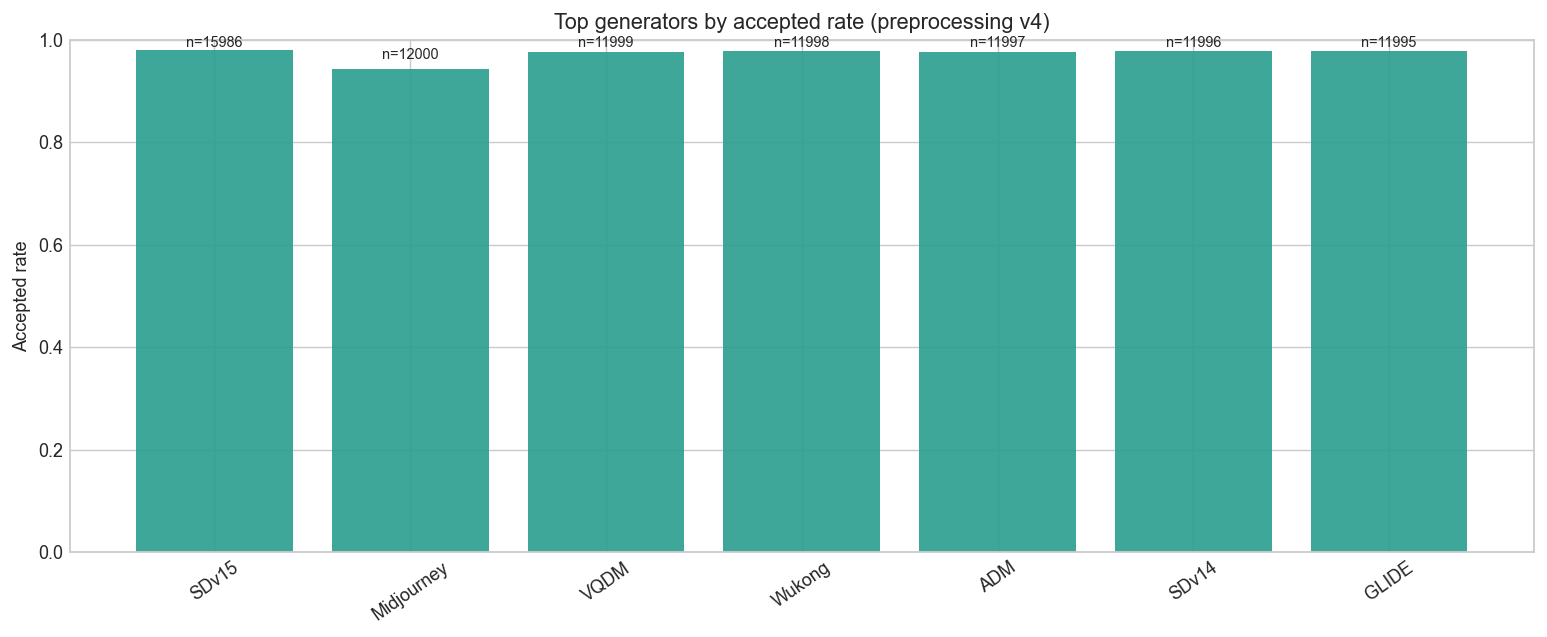

In [46]:
gen_counts = manifest.groupby(['generator', 'status']).size().unstack(fill_value=0)
gen_counts['total'] = gen_counts.sum(axis=1)
gen_counts['accepted_rate'] = gen_counts.get('ACCEPTED', 0.0) / gen_counts['total'].replace(0, np.nan)
top_gen = gen_counts.sort_values('total', ascending=False).head(12).reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_gen['generator'], top_gen['accepted_rate'], color='#2a9d8f', alpha=0.9)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('Accepted rate')
ax.set_title('Top generators by accepted rate (preprocessing v4)')
ax.tick_params(axis='x', rotation=35)
for i, row in top_gen.iterrows():
    ax.text(i, min(0.98, row['accepted_rate'] + 0.015), f"n={int(row['total'])}", ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(PHASE1_PLOT_DIR / 'accepted_rate_by_generator.png', dpi=170)
plt.show()

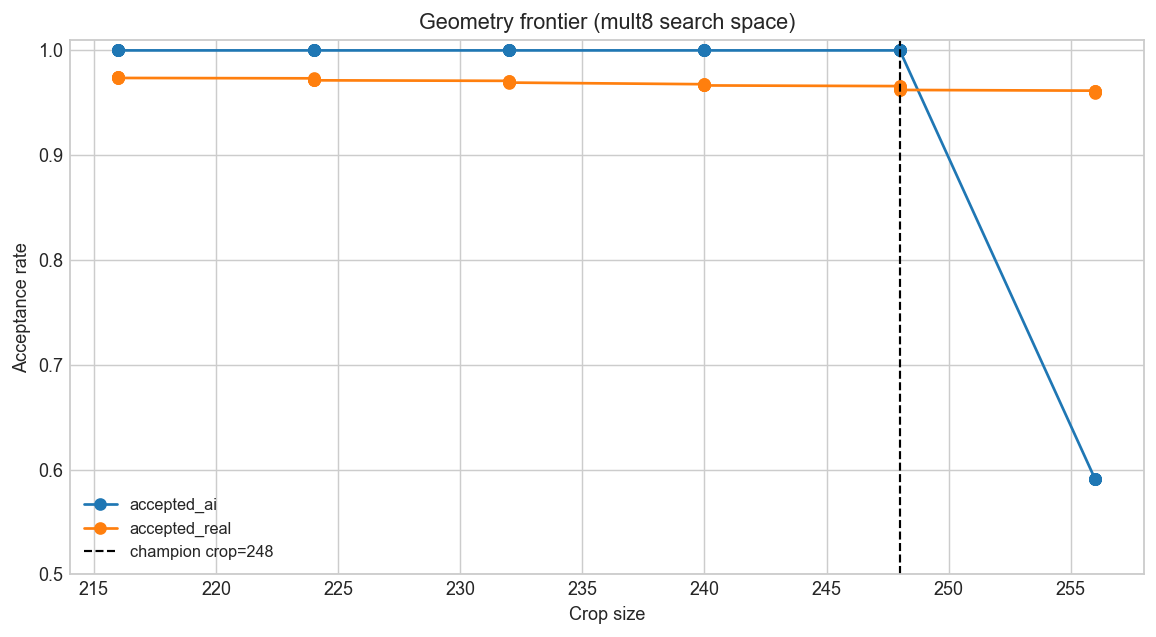

In [47]:
if geometry_frontier is None:
    print('[SKIP] geometry_frontier_mult8.csv not found')
else:
    geometry_frontier['crop_size'] = pd.to_numeric(geometry_frontier['crop_size'], errors='coerce')
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(geometry_frontier['crop_size'], geometry_frontier['accepted_ai'], marker='o', label='accepted_ai')
    ax.plot(geometry_frontier['crop_size'], geometry_frontier['accepted_real'], marker='o', label='accepted_real')
    ax.axvline(248, color='black', linestyle='--', linewidth=1.2, label='champion crop=248')
    ax.set_xlabel('Crop size')
    ax.set_ylabel('Acceptance rate')
    ax.set_title('Geometry frontier (mult8 search space)')
    ax.set_ylim(0.5, 1.01)
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(PHASE1_PLOT_DIR / 'geometry_frontier_acceptance.png', dpi=170)
    plt.show()

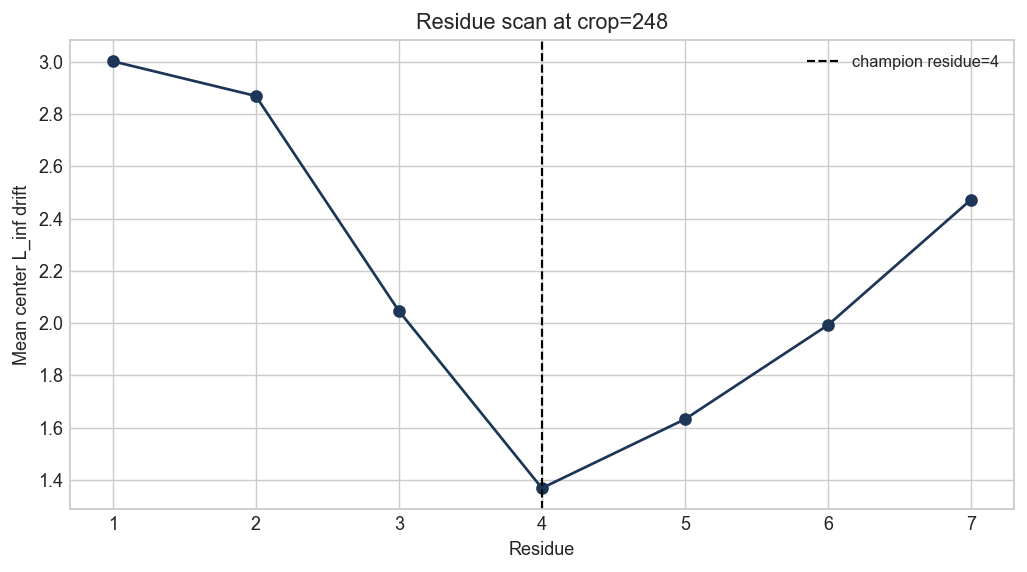

In [48]:
if residue_scan is None:
    print('[SKIP] geometry_residue_scan_crop_248.csv not found')
else:
    residue_scan = residue_scan.sort_values('residue')
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(residue_scan['residue'], residue_scan['mean_center_linf'], marker='o', color='#1d3557')
    ax.axvline(4, color='black', linestyle='--', linewidth=1.2, label='champion residue=4')
    ax.set_xlabel('Residue')
    ax.set_ylabel('Mean center L_inf drift')
    ax.set_title('Residue scan at crop=248')
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(PHASE1_PLOT_DIR / 'residue_scan_crop248.png', dpi=170)
    plt.show()

## Phase 2 - EDA Sau Trich Chon Dac Trung

Phase nay dung feature table v2 va study artifact de xem chat luong feature, overlap theo nhan, tuong quan va trade-off utility/robustness.
Luu y: missingness asymmetry duoc show ro de tranh an branch-shortcut do dropna.

In [49]:
features = load_csv(FEATURE_TABLE_PATH, required=True)
feature_set_metrics = load_csv(FEATURE_SET_METRICS_PATH, required=False)
feature_study_summary = load_json(FEATURE_STUDY_SUMMARY_PATH, required=False)
control_corr = load_csv(CONTROL_CORR_PATH, required=False)
feature_importance = load_csv(FEATURE_IMPORTANCE_PATH, required=False)
features = features.loc[features['status'].astype(str).str.lower().eq('ok')].copy()
meta_cols = {'source_file_path', 'patch_path', 'generator', 'label', 'split_role', 'dataset_name', 'preprocess_version', 'feature_version', 'status', 'error'}
numeric_feature_cols = [c for c in features.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(features[c])]
phase2_summary = {
    'n_rows_ok': int(len(features)),
    'n_numeric_features': int(len(numeric_feature_cols)),
    'split_counts': features['split_role'].value_counts().to_dict(),
    'label_counts': features['label'].value_counts().to_dict(),
    'feature_study_samples': feature_study_summary.get('samples', {}),
}
phase2_summary

{'n_rows_ok': 85615,
 'n_numeric_features': 36,
 'split_counts': {'train_core': 44235,
  'ood_eval': 27410,
  'val': 5821,
  'id_test': 5821,
  'calibration': 2328},
 'label_counts': {'ai': 43992, 'nature': 41623},
 'feature_study_samples': {'common_rows': 85615,
  'label_rows': 1680,
  'shift_rows': 1344,
  'real_nuisance_rows': 1176,
  'label_by_generator_label': {'ADM | ai': 120,
   'ADM | nature': 120,
   'GLIDE | ai': 120,
   'GLIDE | nature': 120,
   'Midjourney | ai': 120,
   'Midjourney | nature': 120,
   'SDv14 | ai': 120,
   'SDv14 | nature': 120,
   'SDv15 | ai': 120,
   'SDv15 | nature': 120,
   'VQDM | ai': 120,
   'VQDM | nature': 120,
   'Wukong | ai': 120,
   'Wukong | nature': 120},
  'real_nuisance_by_subsampling': {'4:2:0': 588, '4:4:4': 588}}}

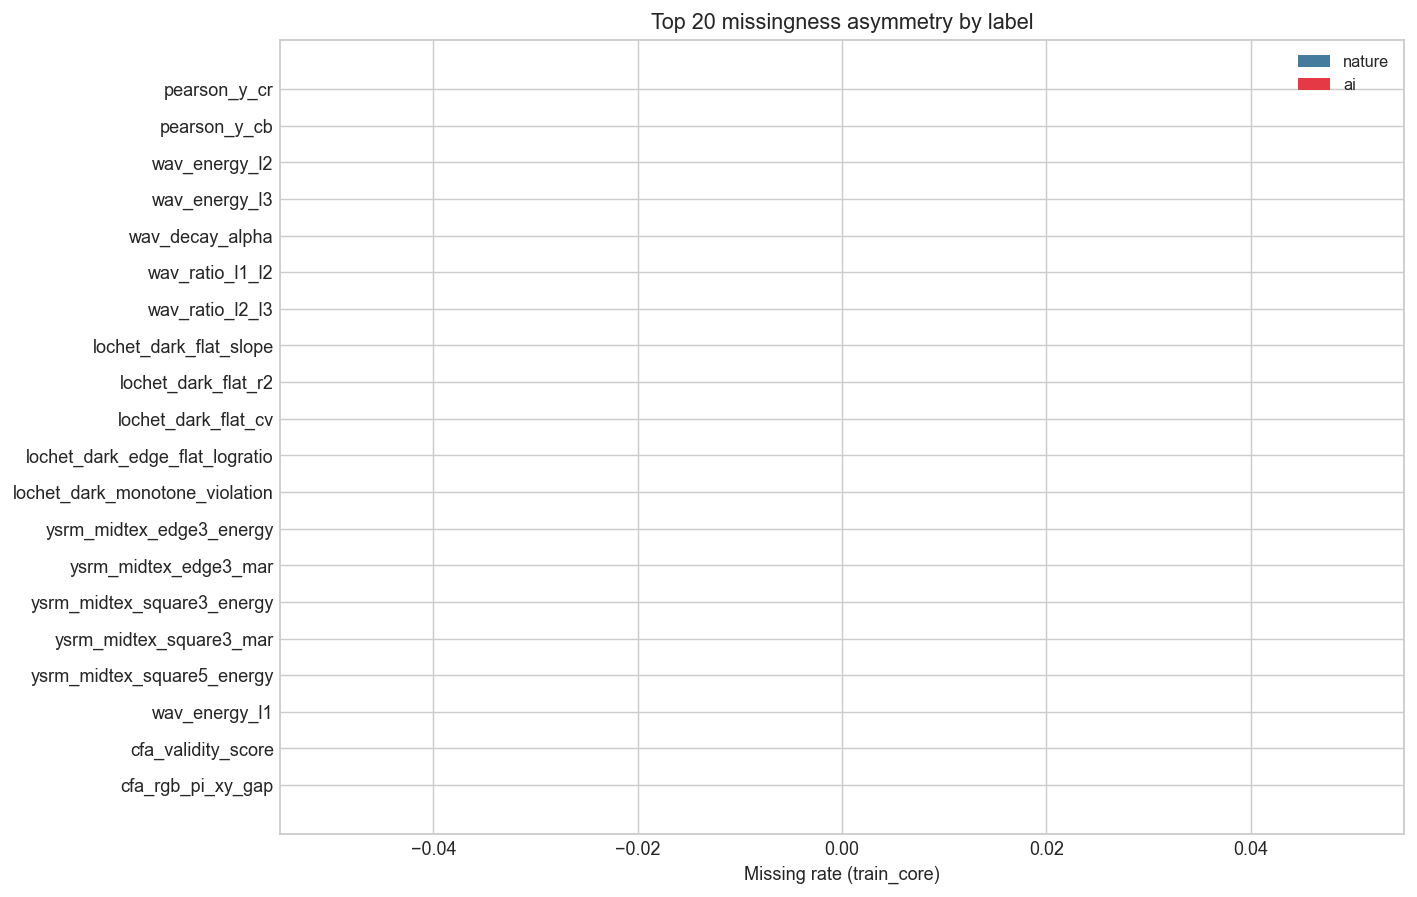

,feature,missing_ai,missing_nature,abs_gap
0,pearson_y_cr,0.0,0.0,0.0
1,pearson_y_cb,0.0,0.0,0.0
20,wav_energy_l2,0.0,0.0,0.0
21,wav_energy_l3,0.0,0.0,0.0
22,wav_decay_alpha,0.0,0.0,0.0
23,wav_ratio_l1_l2,0.0,0.0,0.0
24,wav_ratio_l2_l3,0.0,0.0,0.0
25,lochet_dark_flat_slope,0.0,0.0,0.0
26,lochet_dark_flat_r2,0.0,0.0,0.0
27,lochet_dark_flat_cv,0.0,0.0,0.0


In [50]:
train_for_missing = features.loc[features['split_role'].eq('train_core')].copy()
missing_rows = []
for c in numeric_feature_cols:
    ai_rate = pd.to_numeric(train_for_missing.loc[train_for_missing['label'].eq('ai'), c], errors='coerce').isna().mean()
    nat_rate = pd.to_numeric(train_for_missing.loc[train_for_missing['label'].eq('nature'), c], errors='coerce').isna().mean()
    missing_rows.append({'feature': c, 'missing_ai': float(ai_rate), 'missing_nature': float(nat_rate), 'abs_gap': float(abs(ai_rate - nat_rate))})
missing_by_label = pd.DataFrame(missing_rows).sort_values('abs_gap', ascending=False)
top_gap = missing_by_label.head(20).iloc[::-1]
y = np.arange(len(top_gap))
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(y - 0.18, top_gap['missing_nature'].to_numpy(), height=0.35, label='nature', color='#457b9d')
ax.barh(y + 0.18, top_gap['missing_ai'].to_numpy(), height=0.35, label='ai', color='#e63946')
ax.set_yticks(y)
ax.set_yticklabels(top_gap['feature'].tolist())
ax.set_xlabel('Missing rate (train_core)')
ax.set_title('Top 20 missingness asymmetry by label')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(PHASE2_PLOT_DIR / 'feature_missing_asymmetry_top20.png', dpi=170)
plt.show()
missing_by_label.head(20)

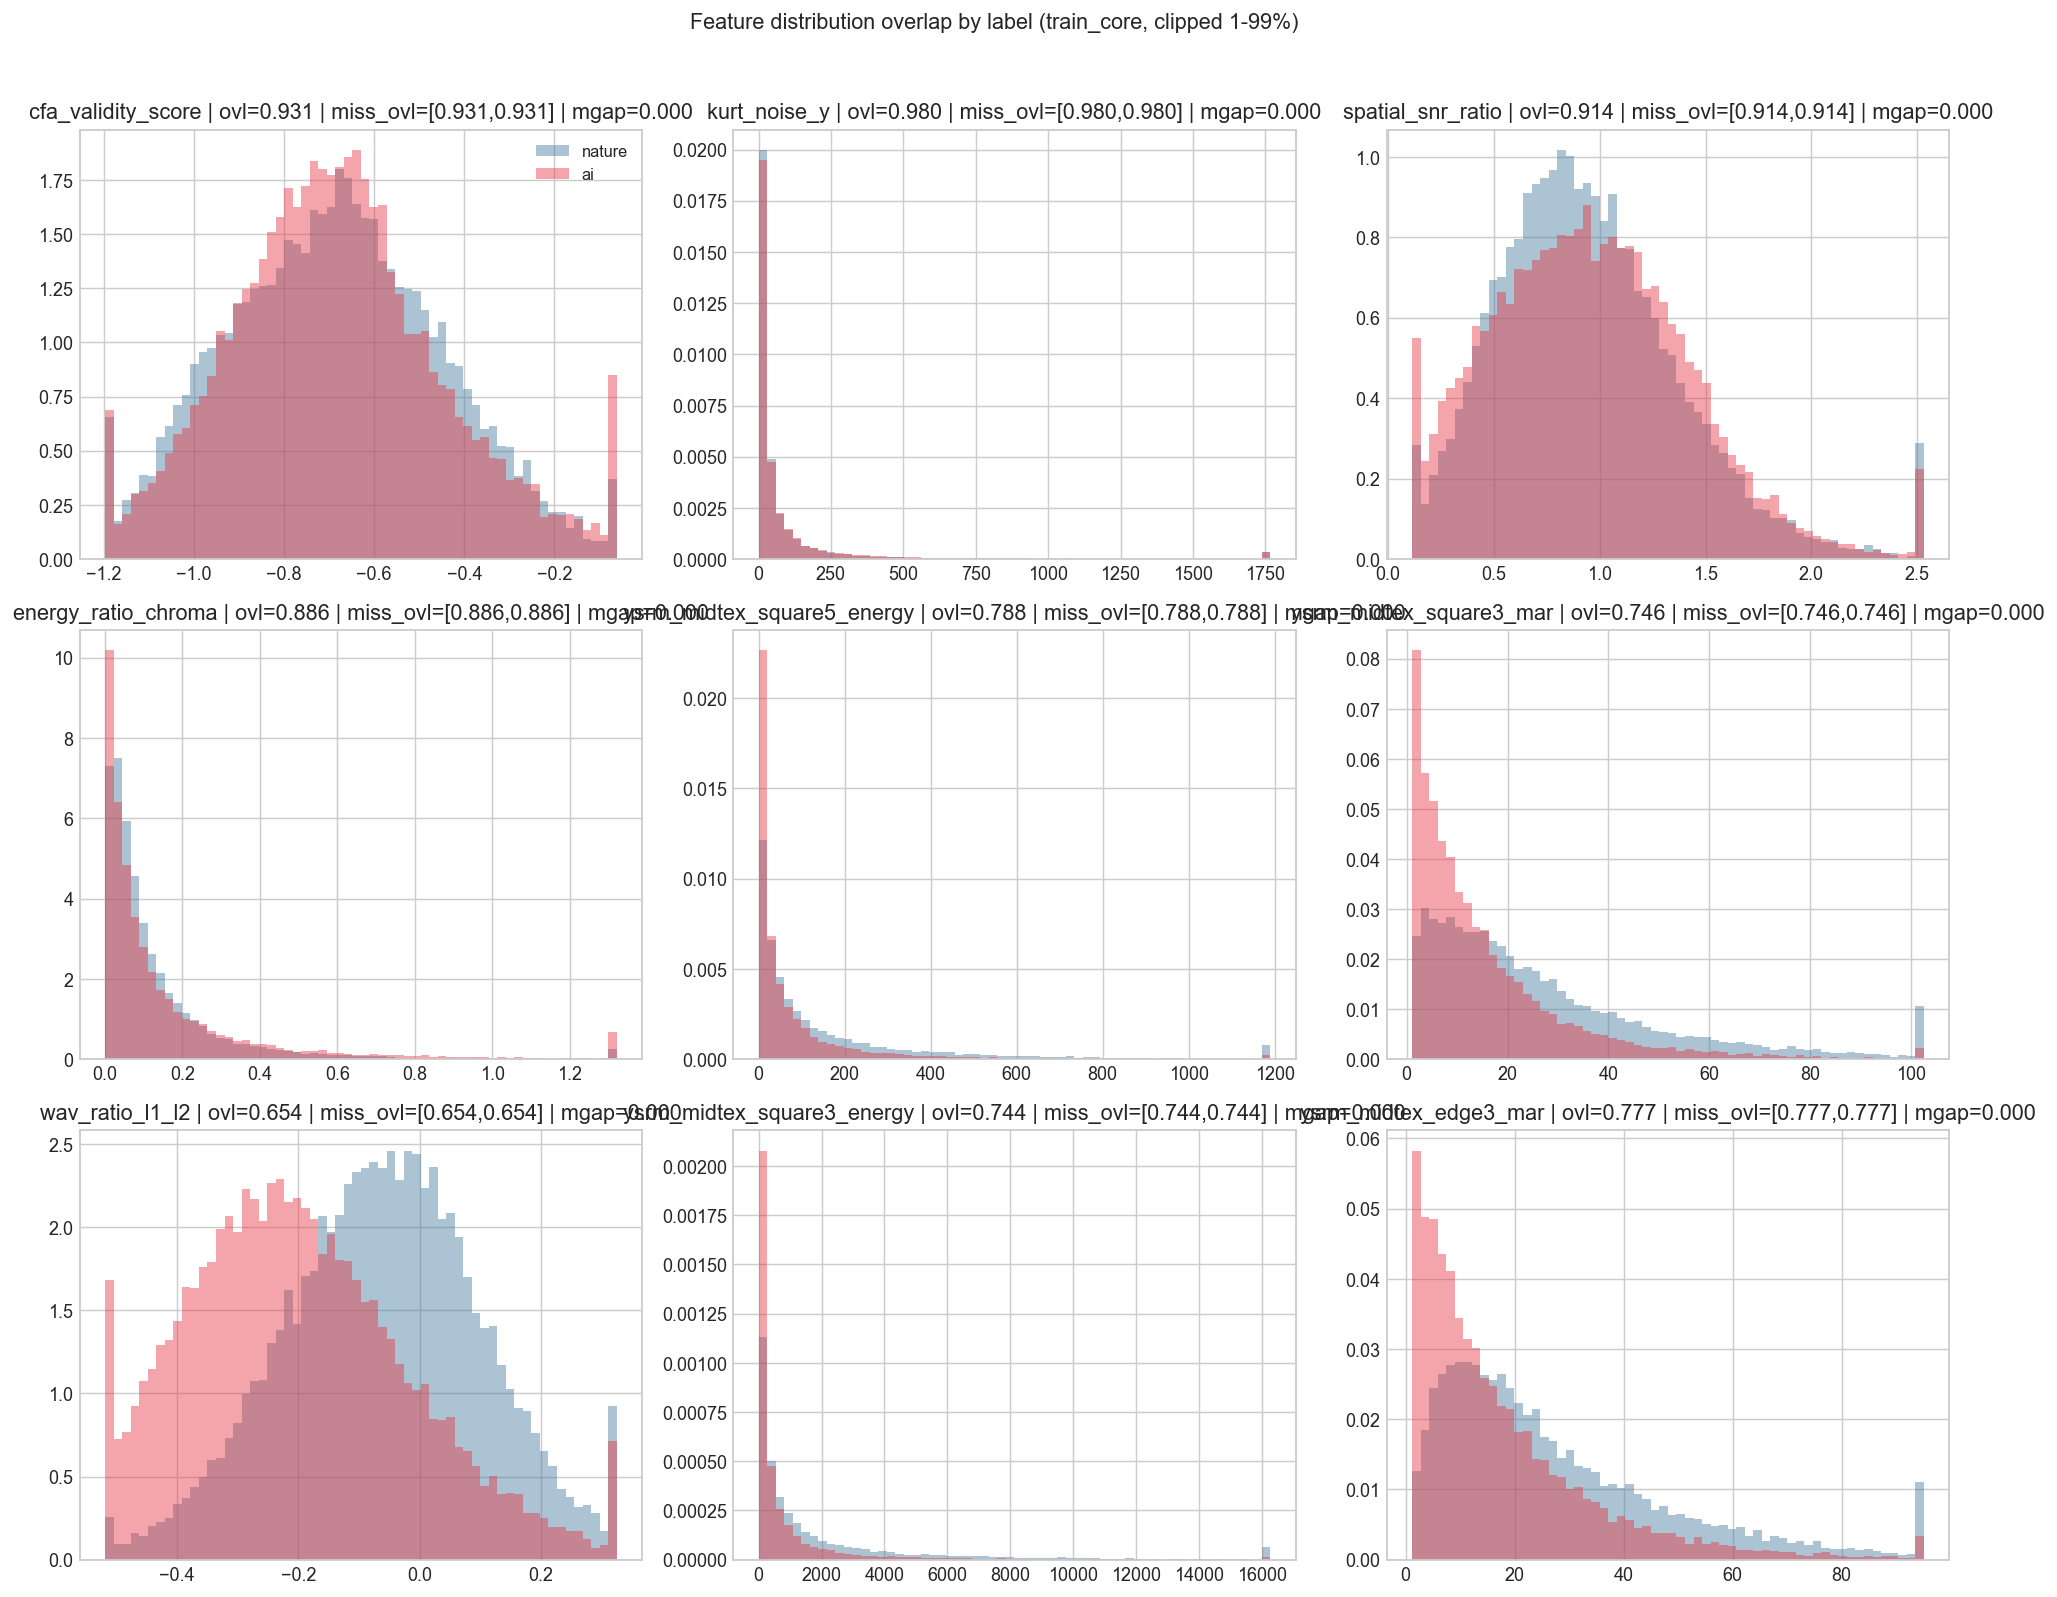

,feature,overlap_coeff_continuous,overlap_coeff_missing_lower,overlap_coeff_missing_upper,missing_ai,missing_nature,missing_gap,n_ai_non_missing,n_nature_non_missing,missingness_proxy_flag
6,wav_ratio_l1_l2,0.654450,0.654450,0.654450,0.0,0.0,0.0,22800,21435,False
7,ysrm_midtex_square3_energy,0.744003,0.744003,0.744003,0.0,0.0,0.0,22800,21435,False
5,ysrm_midtex_square3_mar,0.746278,0.746278,0.746278,0.0,0.0,0.0,22800,21435,False
8,ysrm_midtex_edge3_mar,0.777464,0.777464,0.777464,0.0,0.0,0.0,22800,21435,False
4,ysrm_midtex_square5_energy,0.787735,0.787735,0.787735,0.0,0.0,0.0,22800,21435,False
3,energy_ratio_chroma,0.885996,0.885996,0.885996,0.0,0.0,0.0,22800,21435,False
2,spatial_snr_ratio,0.914182,0.914182,0.914182,0.0,0.0,0.0,22800,21435,False
0,cfa_validity_score,0.931273,0.931273,0.931273,0.0,0.0,0.0,22800,21435,False
1,kurt_noise_y,0.979598,0.979598,0.979598,0.0,0.0,0.0,22800,21435,False


In [51]:
train_df = features.loc[features['split_role'].eq('train_core')].copy()
if train_df.empty:
    raise RuntimeError('No train_core rows found in feature table')
if feature_importance is not None and 'feature' in feature_importance.columns:
    ranked = [f for f in feature_importance['feature'].astype(str).tolist() if f in numeric_feature_cols]
    top_features = ranked[:9]
else:
    top_features = numeric_feature_cols[:9]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
overlap_rows = []
for idx, feature_name in enumerate(top_features):
    ax = axes[idx]
    ai_series = pd.to_numeric(train_df.loc[train_df['label'].eq('ai'), feature_name], errors='coerce')
    nat_series = pd.to_numeric(train_df.loc[train_df['label'].eq('nature'), feature_name], errors='coerce')
    ai_missing = float(ai_series.isna().mean())
    nat_missing = float(nat_series.isna().mean())
    missing_gap = float(abs(ai_missing - nat_missing))
    ai_vals = ai_series.dropna().to_numpy()
    nat_vals = nat_series.dropna().to_numpy()
    if ai_vals.size < 20 or nat_vals.size < 20:
        ax.text(0.5, 0.5, f'{feature_name}\ninsufficient data', ha='center', va='center')
        ax.set_axis_off()
        overlap_rows.append({
            'feature': feature_name,
            'overlap_coeff': float('nan'),
            'missing_ai': ai_missing,
            'missing_nature': nat_missing,
            'missing_gap': missing_gap,
            'n_ai_non_missing': int(ai_vals.size),
            'n_nature_non_missing': int(nat_vals.size),
            'missingness_proxy_flag': bool(missing_gap >= 0.02),
        })
        continue
    combined = np.concatenate([ai_vals, nat_vals])
    q1, q99 = np.nanpercentile(combined, [1, 99])
    ai_clip = np.clip(ai_vals, q1, q99)
    nat_clip = np.clip(nat_vals, q1, q99)
    ovl_continuous = overlap_coefficient(nat_clip, ai_clip, bins=60)
    ovl_missing_lower = min(1.0 - ai_missing, 1.0 - nat_missing) * ovl_continuous
    ovl_missing_upper = min(ai_missing, nat_missing) + ovl_missing_lower
    overlap_rows.append({
        'feature': feature_name,
        'overlap_coeff_continuous': ovl_continuous,
        'overlap_coeff_missing_lower': ovl_missing_lower,
        'overlap_coeff_missing_upper': ovl_missing_upper,
        'missing_ai': ai_missing,
        'missing_nature': nat_missing,
        'missing_gap': missing_gap,
        'n_ai_non_missing': int(ai_vals.size),
        'n_nature_non_missing': int(nat_vals.size),
        'missingness_proxy_flag': bool(missing_gap >= 0.02),
    })
    ax.hist(nat_clip, bins=60, density=True, alpha=0.45, color='#457b9d', label='nature')
    ax.hist(ai_clip, bins=60, density=True, alpha=0.45, color='#e63946', label='ai')
    ax.set_title(f'{feature_name} | ovl={ovl_continuous:.3f} | miss_ovl=[{ovl_missing_lower:.3f},{ovl_missing_upper:.3f}] | mgap={missing_gap:.3f}')
    if idx == 0:
        ax.legend(loc='best')
for j in range(len(top_features), len(axes)):
    axes[j].set_axis_off()
fig.suptitle('Feature distribution overlap by label (train_core, clipped 1-99%)', y=1.02)
fig.tight_layout()
fig.savefig(PHASE2_PLOT_DIR / 'feature_overlap_top9.png', dpi=170)
plt.show()
overlap_df = pd.DataFrame(overlap_rows)
overlap_df.sort_values(['missingness_proxy_flag', 'missing_gap', 'overlap_coeff_missing_lower'], ascending=[False, False, True])

{'corr_mode': 'complete_case', 'corr_rows': 44235, 'corr_row_ratio': 1.0}


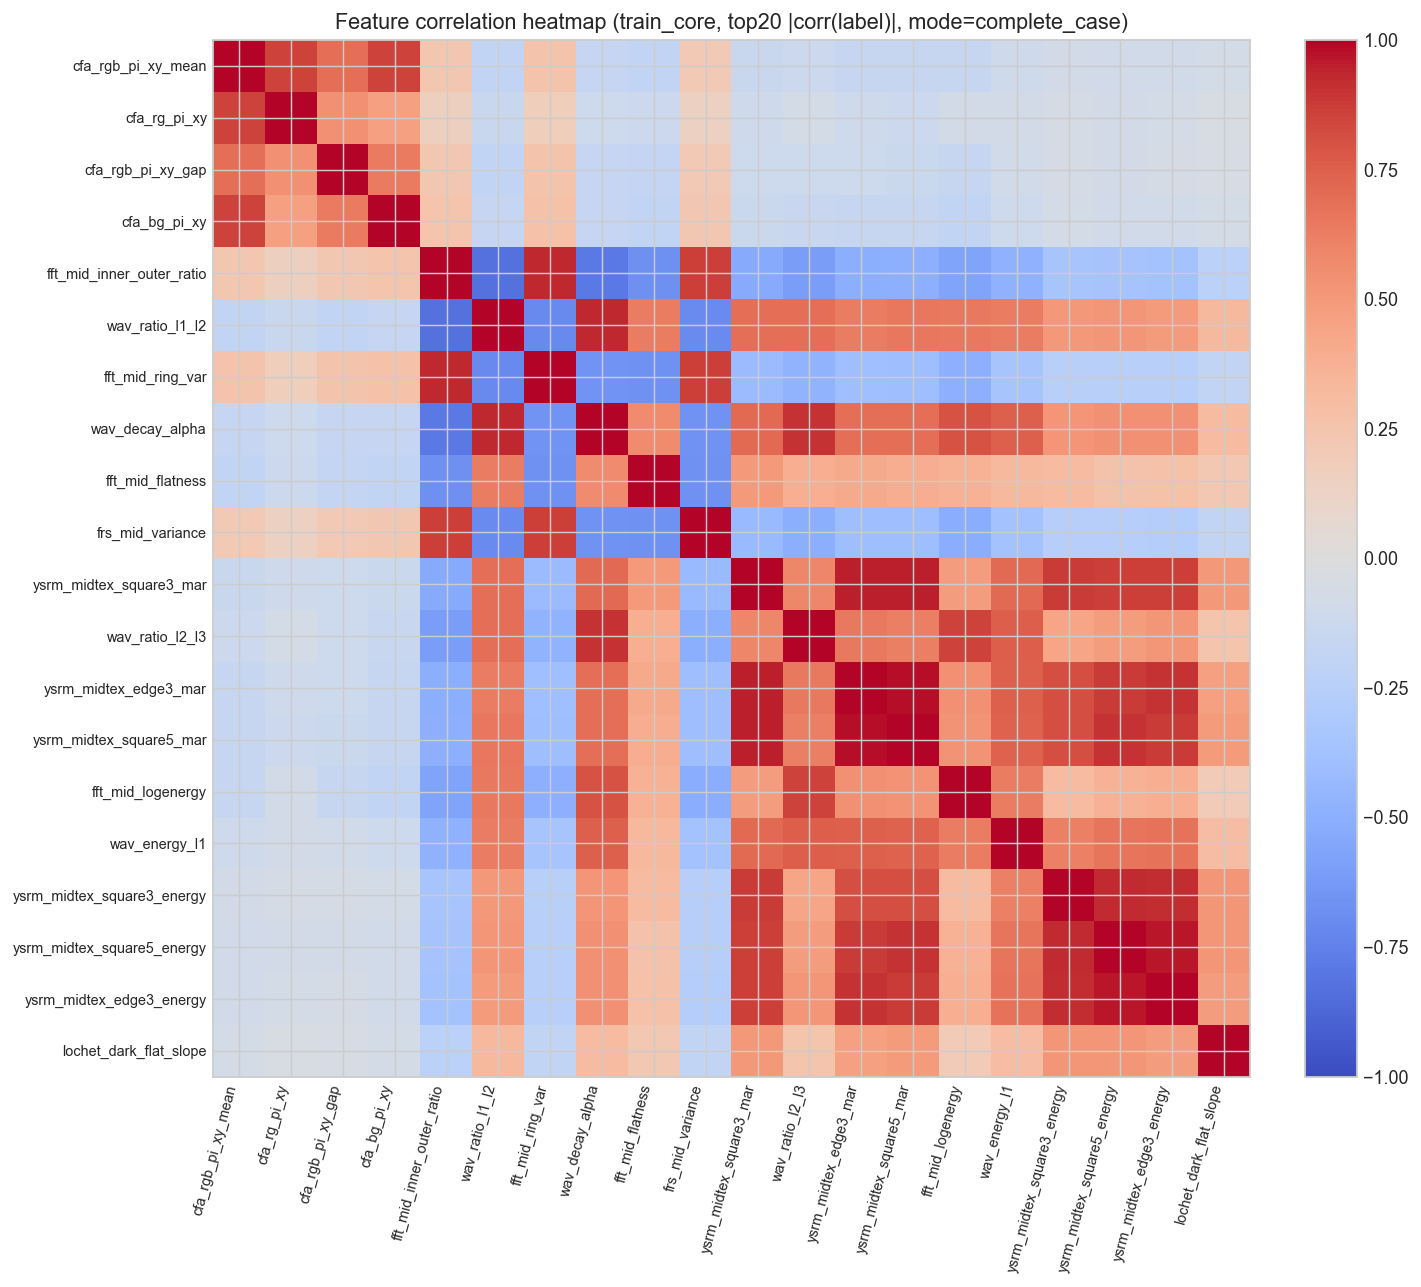

,feature_a,feature_b,corr,n_pair_non_missing
15,ysrm_midtex_edge3_mar,ysrm_midtex_square5_mar,0.979076,44235
24,ysrm_midtex_square5_energy,ysrm_midtex_edge3_energy,0.961043,44235
10,ysrm_midtex_square3_mar,ysrm_midtex_square5_mar,0.946360,44235
9,ysrm_midtex_square3_mar,ysrm_midtex_edge3_mar,0.946212,44235
5,wav_ratio_l1_l2,wav_decay_alpha,0.934368,44235
3,fft_mid_inner_outer_ratio,fft_mid_ring_var,0.930847,44235
22,ysrm_midtex_square3_energy,ysrm_midtex_square5_energy,0.924267,44235
23,ysrm_midtex_square3_energy,ysrm_midtex_edge3_energy,0.915252,44235
18,ysrm_midtex_edge3_mar,ysrm_midtex_edge3_energy,0.904668,44235
7,wav_decay_alpha,wav_ratio_l2_l3,0.902988,44235


In [52]:
target = train_df['label'].map({'nature': 0, 'ai': 1}).astype(float)
feature_label_corr = []
for c in numeric_feature_cols:
    s = pd.to_numeric(train_df[c], errors='coerce')
    corr = s.corr(target)
    ai_missing = float(s.loc[train_df['label'].eq('ai')].isna().mean())
    nat_missing = float(s.loc[train_df['label'].eq('nature')].isna().mean())
    missing_gap = float(abs(ai_missing - nat_missing))
    corr_abs = float(abs(corr)) if pd.notna(corr) else 0.0
    ranking_score = float(max(corr_abs, missing_gap))
    feature_label_corr.append((c, float(corr) if pd.notna(corr) else float('nan'), missing_gap, ranking_score))
top_ranked = sorted(feature_label_corr, key=lambda x: x[3], reverse=True)[:20]
top_corr_features = [name for name, _, _, _ in top_ranked]
pd.DataFrame(top_ranked, columns=['feature', 'corr_with_label', 'missing_gap', 'ranking_score'])
corr_input = train_df[top_corr_features].apply(pd.to_numeric, errors='coerce')
complete_case = corr_input.dropna(axis=0, how='any')
complete_ratio = float(len(complete_case) / len(corr_input)) if len(corr_input) > 0 else float('nan')
if complete_ratio >= 0.9 and len(complete_case) >= 500:
    corr_base = complete_case
    corr_mode = 'complete_case'
else:
    corr_base = corr_input.copy()
    labels = train_df['label']
    for col in top_corr_features:
        global_med = corr_base[col].median()
        for label_name in ['ai', 'nature']:
            label_mask = labels.eq(label_name)
            label_med = corr_base.loc[label_mask, col].median()
            fill_val = label_med if pd.notna(label_med) else global_med
            corr_base.loc[label_mask & corr_base[col].isna(), col] = fill_val
        corr_base[col] = corr_base[col].fillna(global_med)
    corr_mode = 'label_conditional_median_imputed_due_to_low_complete_ratio'
    print('[WARN] Complete-case coverage < 90%; using label-conditional median fallback to reduce survivorship bias.')
corr_mat = corr_base.corr()
print({'corr_mode': corr_mode, 'corr_rows': int(len(corr_base)), 'corr_row_ratio': complete_ratio})
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_mat.to_numpy(), cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(top_corr_features)))
ax.set_xticklabels(top_corr_features, rotation=75, ha='right', fontsize=8)
ax.set_yticks(np.arange(len(top_corr_features)))
ax.set_yticklabels(top_corr_features, fontsize=8)
ax.set_title(f'Feature correlation heatmap (train_core, top20 |corr(label)|, mode={corr_mode})')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(PHASE2_PLOT_DIR / 'feature_correlation_heatmap_top20.png', dpi=170)
plt.show()
notna = corr_input.notna().astype(np.int32)
pair_n = notna.T.dot(notna)
pairs = []
for i, fi in enumerate(top_corr_features):
    for j in range(i + 1, len(top_corr_features)):
        fj = top_corr_features[j]
        val = corr_mat.iloc[i, j]
        if pd.notna(val) and abs(val) >= 0.8:
            pairs.append({'feature_a': fi, 'feature_b': fj, 'corr': float(val), 'n_pair_non_missing': int(pair_n.loc[fi, fj])})
pd.DataFrame(pairs).sort_values('corr', key=lambda s: np.abs(s), ascending=False).head(20) if pairs else pd.DataFrame({'note': ['No |corr| >= 0.8 in top20']})

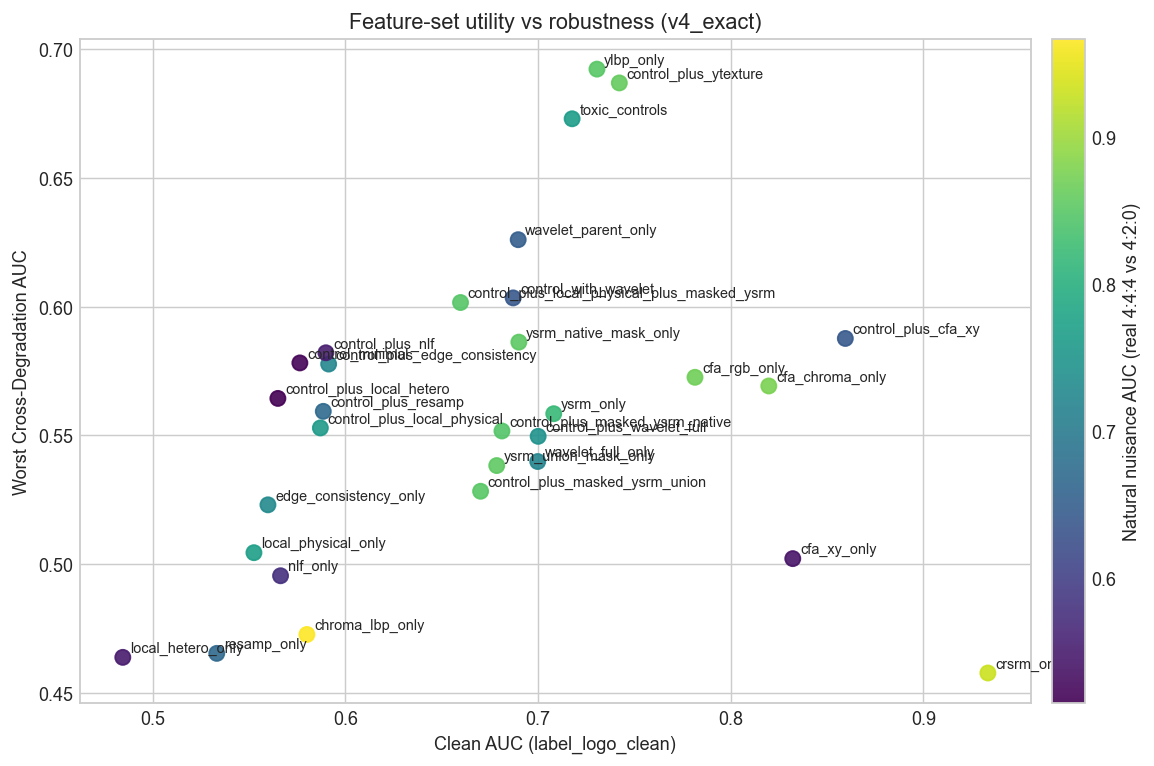

In [53]:
if feature_set_metrics is None:
    print('[SKIP] feature_set_metrics.csv not found')
else:
    v4 = feature_set_metrics.loc[feature_set_metrics['preprocess_version'].eq('v4_exact')].copy()
    clean = v4.loc[v4['task'].eq('label_logo_clean'), ['feature_set', 'auc']].rename(columns={'auc': 'clean_auc'})
    xdeg = v4.loc[v4['task'].astype(str).str.startswith('xdeg_'), ['feature_set', 'auc']].groupby('feature_set', as_index=False)['auc'].min().rename(columns={'auc': 'worst_xdeg_auc'})
    nuis = v4.loc[v4['task'].eq('real_jpeg_444_vs_420'), ['feature_set', 'auc']].rename(columns={'auc': 'nuisance_auc'})
    comp = clean.merge(xdeg, on='feature_set', how='left').merge(nuis, on='feature_set', how='left')
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(comp['clean_auc'], comp['worst_xdeg_auc'], c=comp['nuisance_auc'], cmap='viridis', s=70, alpha=0.9)
    for _, row in comp.iterrows():
        ax.annotate(row['feature_set'], (row['clean_auc'], row['worst_xdeg_auc']), fontsize=8, xytext=(4, 3), textcoords='offset points')
    ax.set_xlabel('Clean AUC (label_logo_clean)')
    ax.set_ylabel('Worst Cross-Degradation AUC')
    ax.set_title('Feature-set utility vs robustness (v4_exact)')
    cb = fig.colorbar(sc, ax=ax, fraction=0.05, pad=0.02)
    cb.set_label('Natural nuisance AUC (real 4:4:4 vs 4:2:0)')
    fig.tight_layout()
    fig.savefig(PHASE2_PLOT_DIR / 'feature_set_utility_vs_robustness.png', dpi=170)
    plt.show()
    comp.sort_values('clean_auc', ascending=False).head(20)

## Phase 3 - EDA Artifact Eval Mo Hinh Sau Train + Kiem Tra Feature

Phase nay doc artifact training baseline de xem ranking candidate, split metrics, OOD, gate coverage, score distribution va importance.
Luu y: CFA gate la artifact cua feature pipeline dieu kien, khong phai preprocess v4_exact contract.

In [54]:
candidate_metrics = load_csv(CANDIDATE_METRICS_PATH, required=True)
selected_metrics = load_csv(SELECTED_METRICS_PATH, required=True)
ood_by_generator = load_csv(OOD_BY_GENERATOR_PATH, required=False)
clean_cfa_gate = load_csv(CLEAN_CFA_GATE_COVERAGE_PATH, required=False)
feat_imp = load_csv(FEATURE_IMPORTANCE_PATH, required=False)
fam_imp = load_csv(FAMILY_IMPORTANCE_PATH, required=False)
auc_nat = load_csv(AUC_NAT_METRICS_PATH, required=False)
degrad_gap = load_csv(DEGRADATION_GAP_PATH, required=False)
branch_close = load_csv(BRANCH_CLOSURE_PATH, required=False)
phase_closure_manifest = load_json(PHASE_CLOSURE_JSON, required=False)
model_manifest = load_json(MODEL_PARAM_DIR / 'model_manifest.json', required=False)
phase3_summary = {
    'candidate_count': int(len(candidate_metrics)),
    'selected_rows': int(len(selected_metrics)),
    'has_ood_by_generator': ood_by_generator is not None,
    'has_cfa_gate': clean_cfa_gate is not None,
    'has_auc_nat': auc_nat is not None,
    'has_degradation_gaps': degrad_gap is not None,
    'has_branch_closure': branch_close is not None,
    'has_phase_closure_manifest': bool(phase_closure_manifest),
    'has_model_manifest': bool(model_manifest),
}
phase3_summary

[SKIP] Missing optional JSON: C:\Users\USER\Desktop\ai_detector_img\models\param\model_manifest.json


{'candidate_count': 10,
 'selected_rows': 4,
 'has_ood_by_generator': True,
 'has_cfa_gate': True,
 'has_auc_nat': True,
 'has_degradation_gaps': True,
 'has_branch_closure': True,
 'has_phase_closure_manifest': True,
 'has_model_manifest': False}

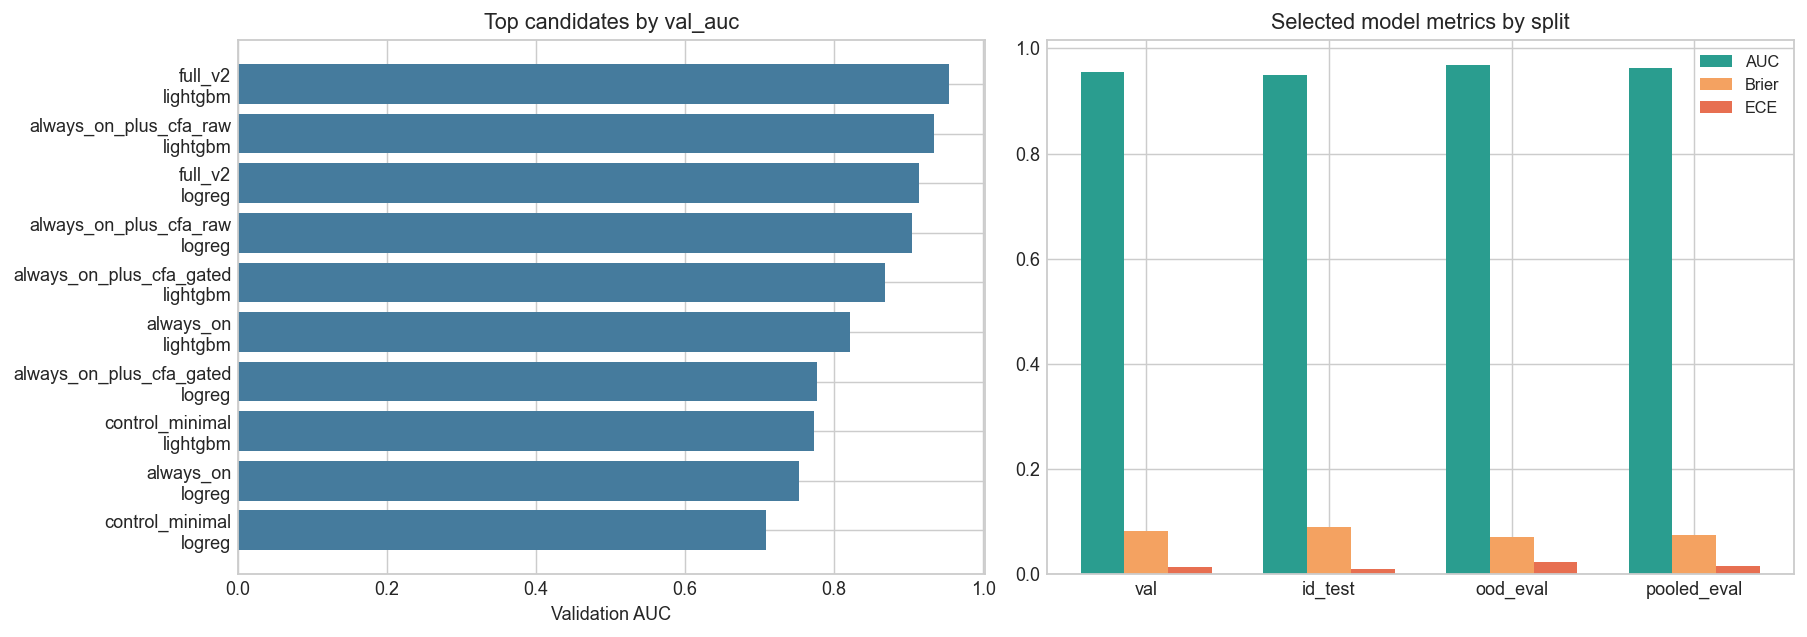

In [55]:
rank = candidate_metrics.sort_values('val_auc', ascending=False).head(10).copy()
rank['candidate_short'] = rank['candidate_name'].astype(str).str.replace('__', '\n', regex=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(rank['candidate_short'][::-1], rank['val_auc'][::-1], color='#457b9d')
axes[0].set_xlabel('Validation AUC')
axes[0].set_title('Top candidates by val_auc')
split_metrics = selected_metrics[['split', 'auc', 'brier', 'ece']].copy()
x = np.arange(len(split_metrics))
w = 0.24
axes[1].bar(x - w, split_metrics['auc'], width=w, label='AUC', color='#2a9d8f')
axes[1].bar(x, split_metrics['brier'], width=w, label='Brier', color='#f4a261')
axes[1].bar(x + w, split_metrics['ece'], width=w, label='ECE', color='#e76f51')
axes[1].set_xticks(x)
axes[1].set_xticklabels(split_metrics['split'])
axes[1].set_title('Selected model metrics by split')
axes[1].legend(loc='best')
fig.tight_layout()
fig.savefig(PHASE3_PLOT_DIR / 'candidate_ranking_and_split_metrics.png', dpi=170)
plt.show()

[NOTE] CFA gate coverage is a model-feature artifact, not preprocessing v4_exact contract evidence.


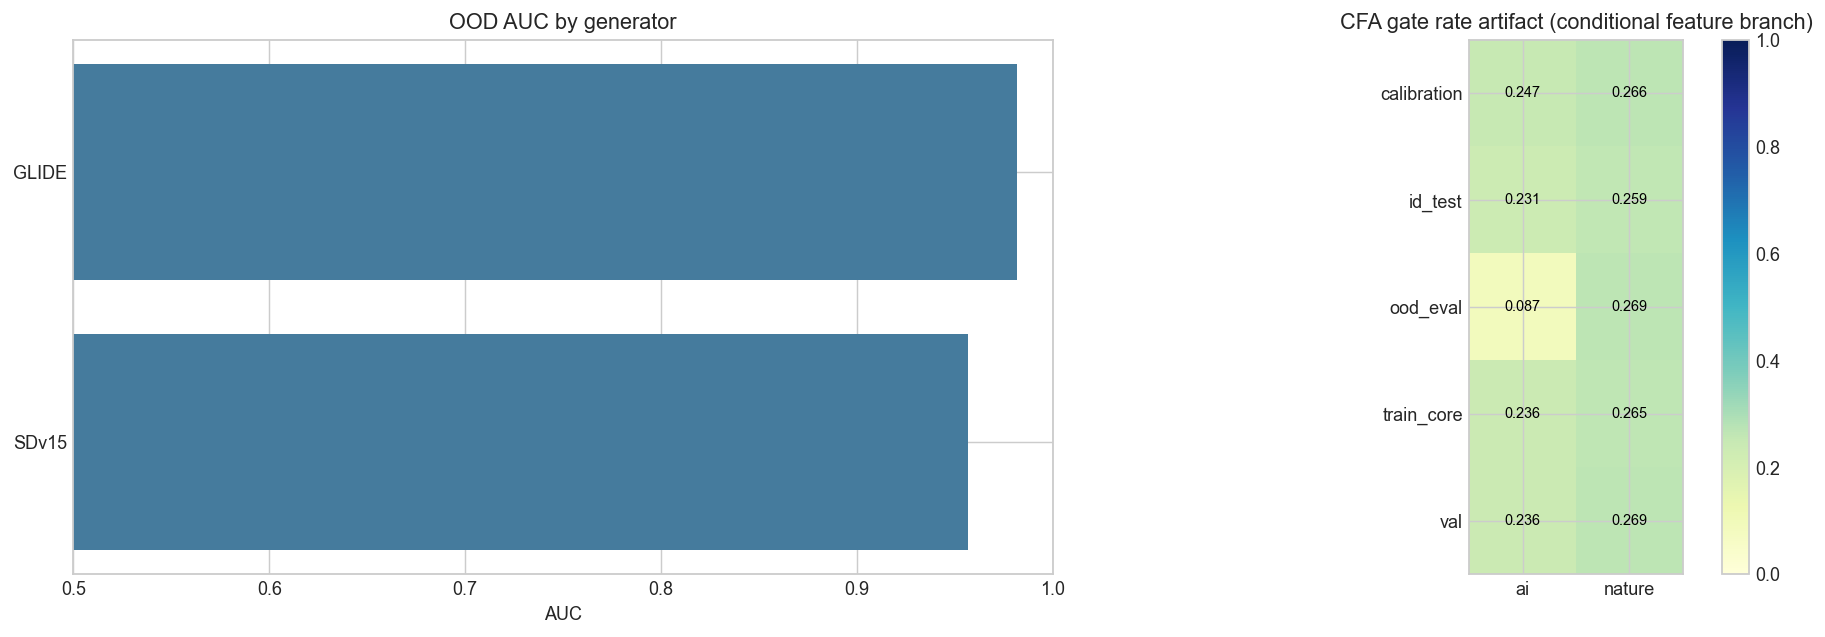

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if ood_by_generator is None or ood_by_generator.empty:
    axes[0].text(0.5, 0.5, 'Missing OOD by generator artifact', ha='center', va='center')
    axes[0].set_axis_off()
else:
    ood = ood_by_generator.sort_values('auc', ascending=True)
    axes[0].barh(ood['generator'], ood['auc'], color='#457b9d')
    axes[0].set_xlim(0.5, 1.0)
    axes[0].set_xlabel('AUC')
    axes[0].set_title('OOD AUC by generator')
if clean_cfa_gate is None or clean_cfa_gate.empty:
    axes[1].text(0.5, 0.5, 'Missing CFA gate coverage artifact', ha='center', va='center')
    axes[1].set_axis_off()
else:
    pivot = clean_cfa_gate.pivot(index='split_role', columns='label', values='gate_rate').sort_index()
    im = axes[1].imshow(pivot.to_numpy(), cmap='YlGnBu', vmin=0.0, vmax=1.0)
    axes[1].set_xticks(np.arange(pivot.shape[1]))
    axes[1].set_xticklabels(pivot.columns.tolist())
    axes[1].set_yticks(np.arange(pivot.shape[0]))
    axes[1].set_yticklabels(pivot.index.tolist())
    axes[1].set_title('CFA gate rate artifact (conditional feature branch)')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.iloc[i, j]
            axes[1].text(j, i, f'{v:.3f}', ha='center', va='center', color='black', fontsize=8)
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    print('[NOTE] CFA gate coverage is a model-feature artifact, not preprocessing v4_exact contract evidence.')
fig.tight_layout()
fig.savefig(PHASE3_PLOT_DIR / 'ood_and_cfa_gate.png', dpi=170)
plt.show()

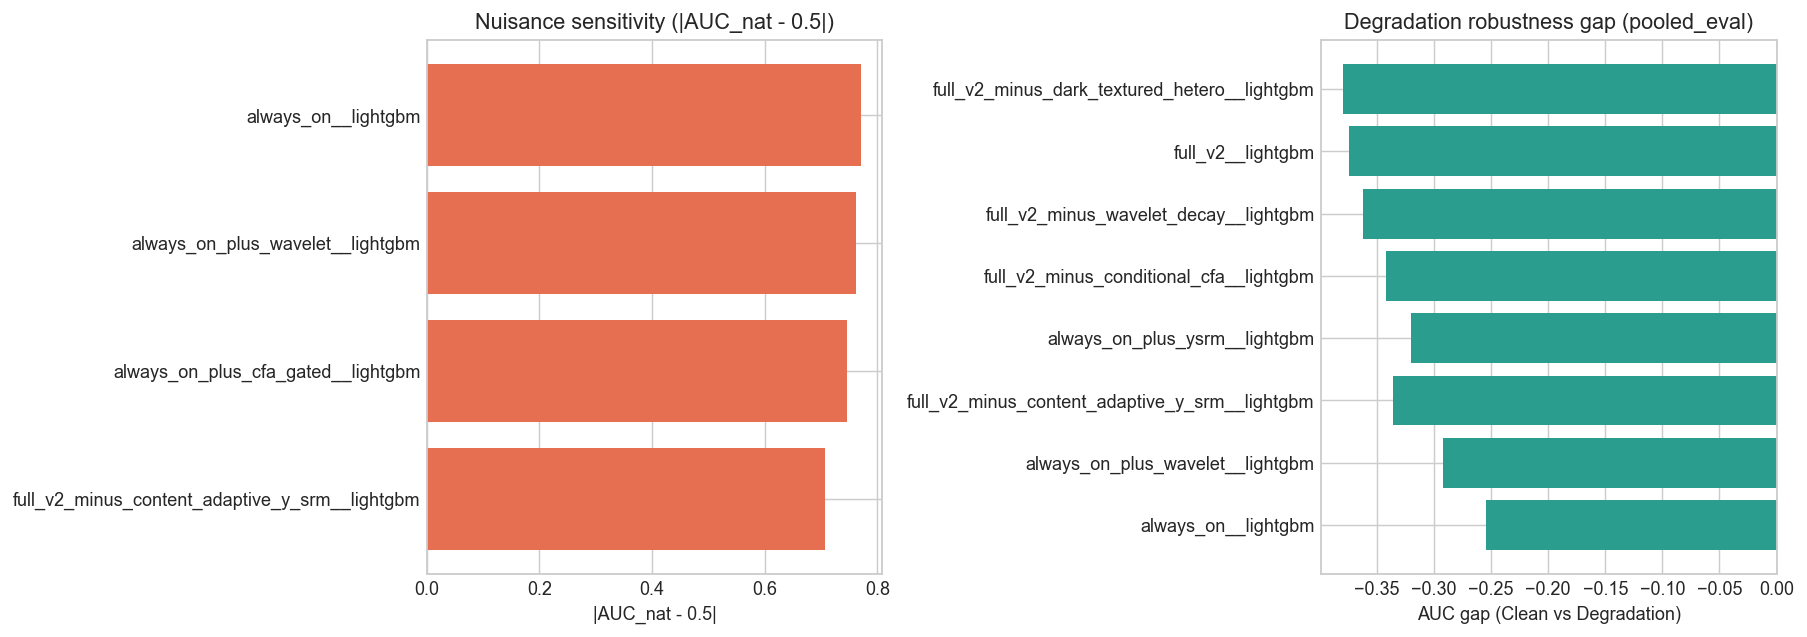

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if auc_nat is None or auc_nat.empty:
    axes[0].text(0.5, 0.5, 'Missing model-level AUC_nat artifact', ha='center', va='center')
    axes[0].set_axis_off()
else:
    nat_df = auc_nat.sort_values('auc_nat_abs', ascending=False).head(15)
    axes[0].barh(nat_df['candidate_name'][::-1], nat_df['auc_nat_abs'][::-1], color='#e76f51')
    axes[0].set_xlabel('|AUC_nat - 0.5|')
    axes[0].set_title('Nuisance sensitivity (|AUC_nat - 0.5|)')
if degrad_gap is None or degrad_gap.empty:
    axes[1].text(0.5, 0.5, 'Missing degradation gap artifact', ha='center', va='center')
    axes[1].set_axis_off()
else:
    deg_pool = degrad_gap.loc[degrad_gap['split'].eq('pooled_eval')].sort_values('auc_gap', ascending=True).head(15)
    axes[1].barh(deg_pool['candidate_name'][::-1], deg_pool['auc_gap'][::-1], color='#2a9d8f')
    axes[1].set_xlabel('AUC gap (Clean vs Degradation)')
    axes[1].set_title('Degradation robustness gap (pooled_eval)')
fig.tight_layout()
fig.savefig(PHASE3_PLOT_DIR / 'nuisance_and_degradation_gaps.png', dpi=170)
plt.show()

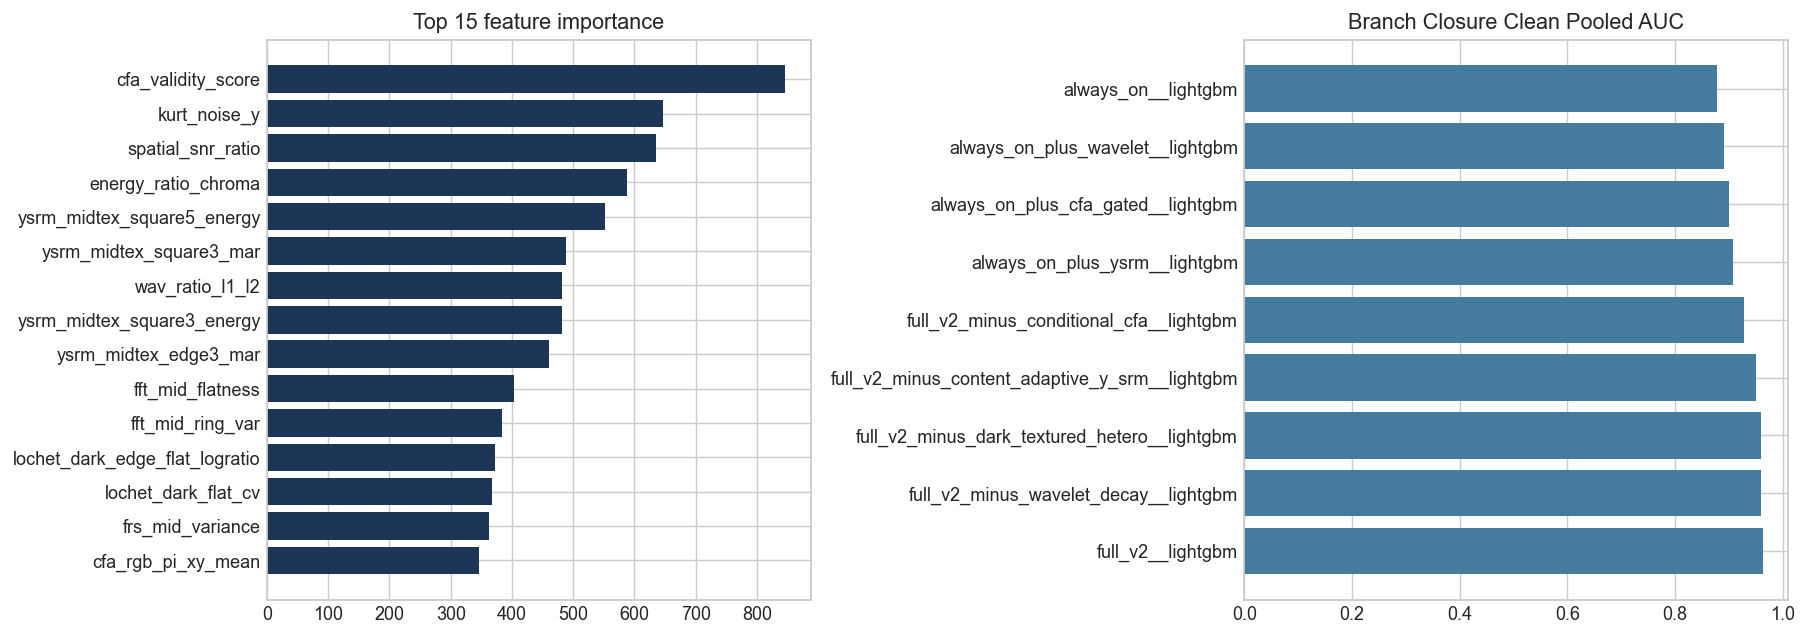

{'feature_table_path': 'C:\\Users\\USER\\Desktop\\ai_detector_img\\features\\feature_extraction_v2_rgb248_exact.csv',
 'rows': 85615,
 'feature_version': 'v2_rgb248_exact_multibranch',
 'preprocess_version': 'v4_rgb248_r4_exact',
 'selected_clean_candidate': 'full_v2__lightgbm',
 'selected_clean_feature_set': 'full_v2',
 'selected_clean_model_name': 'lightgbm',
 'selected_clean_val_auc': 0.9548272480207964,
 'selected_clean_threshold': 0.7074744498826763,
 'required_audits_completed': True,
 'best_branch_candidate': 'full_v2__lightgbm',
 'best_branch_feature_set': 'full_v2',
 'best_branch_clean_pooled_auc': 0.9628714733532449,
 'best_branch_worst_xdeg_auc': 0.5886909984350508,
 'best_branch_auc_nat_abs': 0.6710345966170204,
 'phase1_files': {'candidate_val_metrics_csv': 'C:\\Users\\USER\\Desktop\\ai_detector_img\\audit_output\\validation\\training_v2_phase_closure_20260403\\phase1_clean_benchmark\\candidate_val_metrics.csv',
  'selected_model_metrics_csv': 'C:\\Users\\USER\\Desktop\\ai

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if feat_imp is None or feat_imp.empty:
    axes[0].text(0.5, 0.5, 'Missing feature importance artifact', ha='center', va='center')
    axes[0].set_axis_off()
else:
    top_feat = feat_imp.sort_values('importance', ascending=True).tail(15)
    axes[0].barh(top_feat['feature'], top_feat['importance'], color='#1d3557')
    axes[0].set_title('Top 15 feature importance')
if branch_close is None or branch_close.empty:
    axes[1].text(0.5, 0.5, 'Missing branch_closure_summary artifact', ha='center', va='center')
    axes[1].set_axis_off()
else:
    b_pool = branch_close.sort_values('clean_pooled_auc', ascending=True).tail(10)
    axes[1].barh(b_pool['candidate_name'][::-1], b_pool['clean_pooled_auc'][::-1], color='#457b9d')
    axes[1].set_title('Branch Closure Clean Pooled AUC')
fig.tight_layout()
fig.savefig(PHASE3_PLOT_DIR / 'importance_and_branch_closure.png', dpi=170)
plt.show()
phase_closure_manifest